In [1]:
import numpy as np
import scipy
import matplotlib
import mne
from mne.datasets import eegbci
from pathlib import Path

In [5]:
data_dir = Path.home() / "projects" / "bci" / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)
subject = 1
runs = list(range(1, 15))
print(f"Downloading subject {subject}, {len(runs)} runs...")
fnames = eegbci.load_data(subjects=[subject], runs=runs, path=str(data_dir))

print(f"\n✅ Downloaded {len(fnames)} files")
for f in fnames[:3]:
    print(" ", f)
print(" ...")

Attempting to create new mne-python configuration file:
/home/beecki303/.mne/mne-python.json
Could not read the /home/beecki303/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 03m20s (32.2 MB)

✅ Downloaded 14 files
  /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf
  /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R02.edf
  /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf
 ...


In [6]:
# Load the first run — 1 minute baseline with eyes open
raw = mne.io.read_raw_edf(fnames[0], preload=True)

# Print basic info about the recording
print(raw.info)
print(f"\nDuration: {raw.times[-1]:.1f} seconds")
print(f"Sample rate: {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"First 10 channels: {raw.ch_names[:10]}")

Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

Duration: 61.0 seconds
Sample rate: 160.0 Hz
Number of channels: 64
First 10 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']


In [7]:
# Strip the trailing periods from channel names
mne.datasets.eegbci.standardize(raw)

# Apply standard 10-05 montage (electrode positions for plotting)
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)

print("Cleaned channel names (first 10):", raw.ch_names[:10])
print("✅ Montage applied")

Cleaned channel names (first 10): ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']
✅ Montage applied


Using matplotlib as 2D backend.


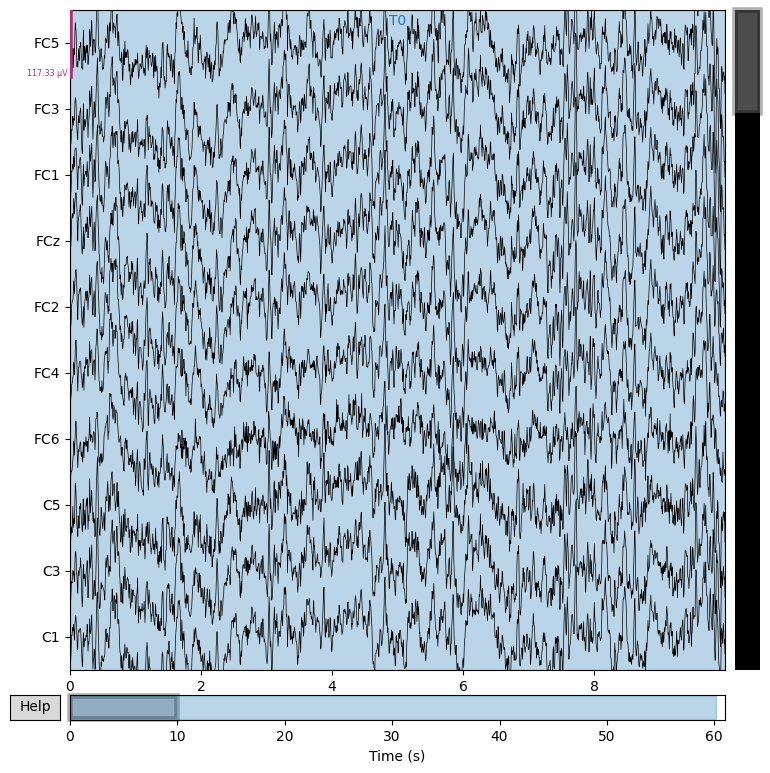

In [8]:
%matplotlib inline

# Plot the first 10 seconds of raw EEG
raw.plot(duration=10, n_channels=10, scalings='auto', show=True);